# Chapter 2: Database System Concepts and Architecture


## Teaching Summary

How can stored data change without every program having to be rewritten? This
chapter distinguishes descriptions, current values, user views, and storage details.
Read Chapter 1 first. The supplied code is for observing results; you do not need
to write Python or SQL in this meeting.

Textbook: Elmasri and Navathe, *Fundamentals of Database Systems*, seventh edition,
introductory selections from Sections 2.1-2.3 and 2.5. All diagrams and student data
are original teaching examples. These selections do not cover every DBMS architecture.

After reading, you should be able to distinguish a schema from a state, classify
a logical versus physical independence example, identify DDL and DML by purpose,
and distinguish an embedded SQLite example from a client/server arrangement.


## 1. A Model Describes What We Represent

A **data model** supplies concepts for describing data, relationships, and constraints.
Different model levels expose different details. A conceptual description can say
that a student belongs to a department. A relational description can represent that
fact using attributes in tables. A physical description concerns how records and
access structures are stored.

Suppose S101 belongs to IM. The three panels below describe that same fact at
different levels. They are not three separate students or a requirement to build
three applications. Formal ER notation is taught later; the first panel is an
informal description, not a finished ER diagram.

**Predict:** Which panel is useful for deciding what a student-department association
means? Which panel concerns locating stored records?


### One student-department fact, three descriptions

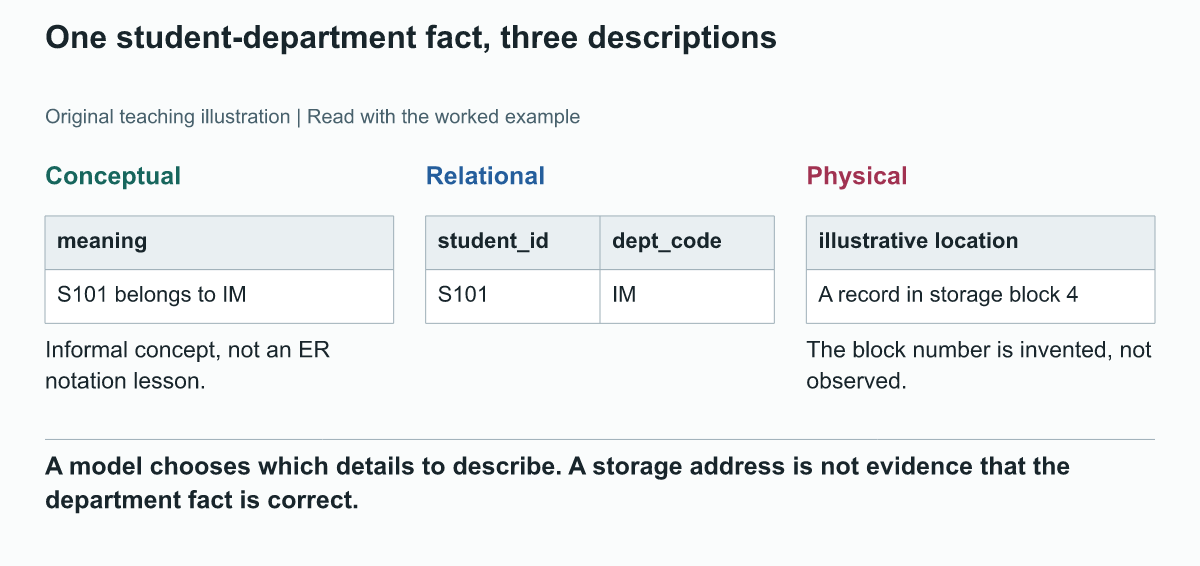

A model chooses which details to describe. A storage address is not evidence that the department fact is correct.


### Read the Diagram

The conceptual panel describes the association. The relational panel gives attribute
names and values. The physical panel concerns storage locations. Physical location
does not tell us whether the student's department is factually correct.

**Practice:** Describe a course title at each of these levels. Do not invent a disk
address as evidence about a real database; use an explicitly illustrative location.


## 2. Schema and Database State

A **schema** describes the database structure and its constraints. A **database state**
is the data stored at a particular point. The book also uses **snapshot** for a state;
some sources call it an instance. Here we use state because instance can also mean
an individual row in other contexts.

`student(student_id, student_name, dept_code)` names a relation and its attributes.
The values `(S101, An Chen, IM)` are a row in a particular state. Inserting another
student changes the state, not those attribute names. Adding a new attribute changes
the schema, and existing rows then have values for that attribute as well.

**Predict:** For the three operations in the diagram, which changes the schema?
Which changes the number of rows? Which changes a stored value without adding a row?


### Count rows and attributes separately

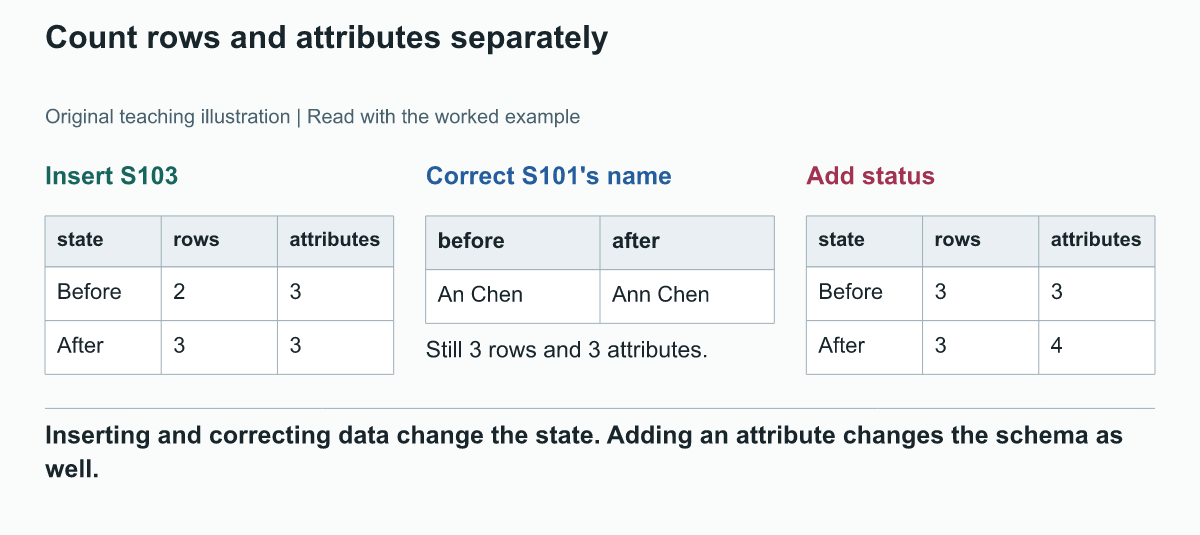

Inserting and correcting data change the state. Adding an attribute changes the schema as well.


### Read the Diagram

Inserting S103 changes two rows to three. Correcting S101's name changes one value
but leaves three rows. Adding `status` changes the schema from three attributes to
four. These operations are different even though each affects what a display can show.


### Observe the Changes

Run this cell in a fresh notebook kernel. It uses a new in-memory database each time
and closes it afterward. Predict the row and attribute counts before running it.
The commands are supplied; SQL authoring begins in Chapter 6.


In [1]:
import sqlite3

db = sqlite3.connect(":memory:", isolation_level=None)
try:
    db.execute("CREATE TABLE student (student_id TEXT, student_name TEXT, dept_code TEXT)")
    db.executemany("INSERT INTO student VALUES (?, ?, ?)", [
        ("S101", "An Chen", "IM"), ("S102", "Bea Lin", "FIN")
    ])

    def show_state(label):
        rows = db.execute("SELECT * FROM student ORDER BY student_id").fetchall()
        columns = db.execute("PRAGMA table_info(student)").fetchall()
        print(f"{label}: {len(rows)} rows, {len(columns)} attributes")
        print(rows[0])

    show_state("Start")
    db.execute("INSERT INTO student VALUES ('S103', 'Kai Wu', 'IM')")
    show_state("Add a student")
    db.execute("UPDATE student SET student_name='Ann Chen' WHERE student_id='S101'")
    show_state("Correct a name")
    db.execute("ALTER TABLE student ADD COLUMN status TEXT NOT NULL DEFAULT 'active'")
    show_state("Add an attribute")
finally:
    db.close()


Start: 2 rows, 3 attributes
('S101', 'An Chen', 'IM')
Add a student: 3 rows, 3 attributes
('S101', 'An Chen', 'IM')
Correct a name: 3 rows, 3 attributes
('S101', 'Ann Chen', 'IM')
Add an attribute: 3 rows, 4 attributes
('S101', 'Ann Chen', 'IM', 'active')


The final S101 row has four values, including `active`. The name correction did not
add a student. The successful ADD COLUMN operation demonstrates a schema change;
it does not prove that every application can tolerate that change.

**Practice:** A course description is corrected, then a new course is inserted.
For each operation, state whether the schema, a value, or the row count changes.
Check your reasoning against the kind of change, not the size of the edited text.


## 3. Three Schema Levels

The **three-schema architecture** distinguishes external, conceptual, and internal
descriptions. An **external schema** describes a particular user's view. The
**conceptual schema** describes the database as a whole at the conceptual level.
The **internal schema** describes storage structures and access paths.

For our example, the contact office sees IDs and emails. The database description
also includes departments. The storage description explains how the records can be
located. The mappings connect these descriptions; the levels are not three independent
copies of the student facts.

**Predict:** Where should the contact office's attribute selection appear? Where
should storage-location details appear?


### Three descriptions, not three copies of the facts

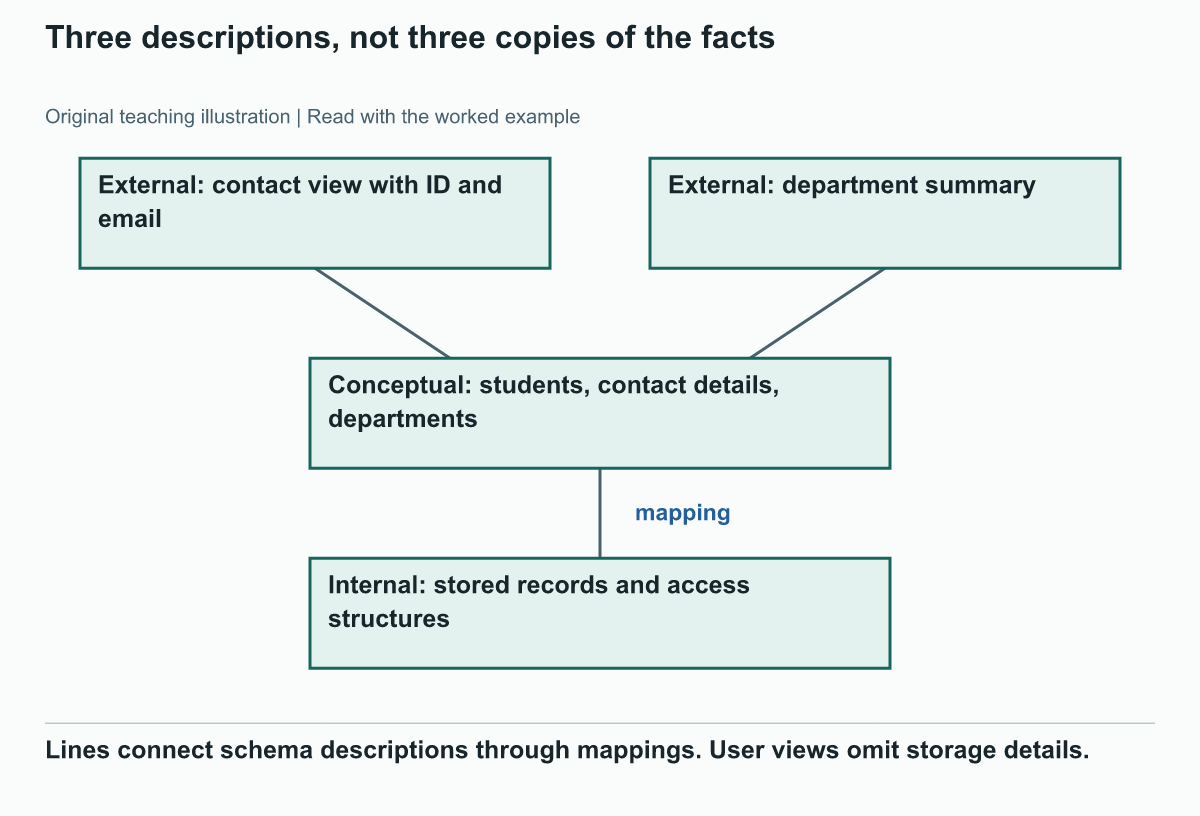

Lines connect schema descriptions through mappings. User views omit storage details.


### Read the Diagram

The contact selection belongs at the external level, while storage details belong
at the internal level. The conceptual level connects the database-wide meanings.
Real products need not implement three separately named schema components; the
architecture explains the separation we want to reason about.

**Practice:** Place a department-summary view and a record-location change at their
appropriate levels. Name what each description exposes and what it leaves out.


## 4. Data Independence Has Conditions

**Logical data independence** is the ability to change the conceptual schema without
having to change external schemas or their application programs. Mappings may need
to be changed to preserve what those users see. **Physical data independence** is
the ability to change the internal schema without changing the conceptual schema.

Consider two illustrative changes. First, a designer separates contact details into
another relation but maintains an external contact view with the same attributes,
rows, and meanings. Second, an administrator adds an access structure while retaining
the same logical tables and query answers. Neither example promises that every
possible program or performance measurement is unchanged.

**Predict:** Which change is logical and which is physical? For each, name exactly
what must remain unchanged before you can claim the relevant independence.


### What changes, and what must stay the same?

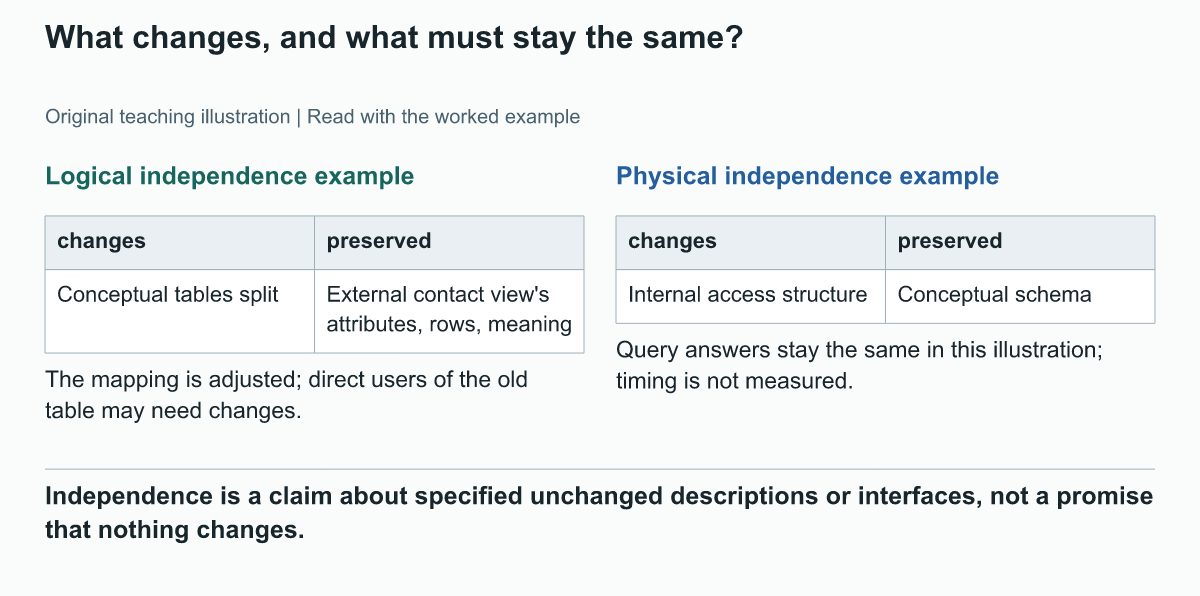

Independence is a claim about specified unchanged descriptions or interfaces, not a promise that nothing changes.


### Read the Diagram

The split demonstrates logical data independence only under the stated preserved-view
condition. A program that directly depends on the old table instead of that view may need revision.
The added access structure is a physical change if the conceptual schema is unchanged.
This is a conceptual comparison, not a measured speedup or a live index experiment.

**Practice:** A designer renames an exposed attribute and an application fails to
find it. Explain why this is not evidence of successful logical independence for
that application. Identify the interface that failed to remain stable.


## 5. Database Languages Express Different Requests

**Data definition language (DDL)** describes structure. **Data manipulation language
(DML)** retrieves or changes data. SQL includes both kinds of statements, so they
need not be separate software products. We classify statements by their purpose here,
not by requiring you to memorize their syntax.

**Predict:** Does requesting S101's department define a new column? Does adding the
`status` attribute merely change a student's existing value?


### Structure and data requests have different purposes

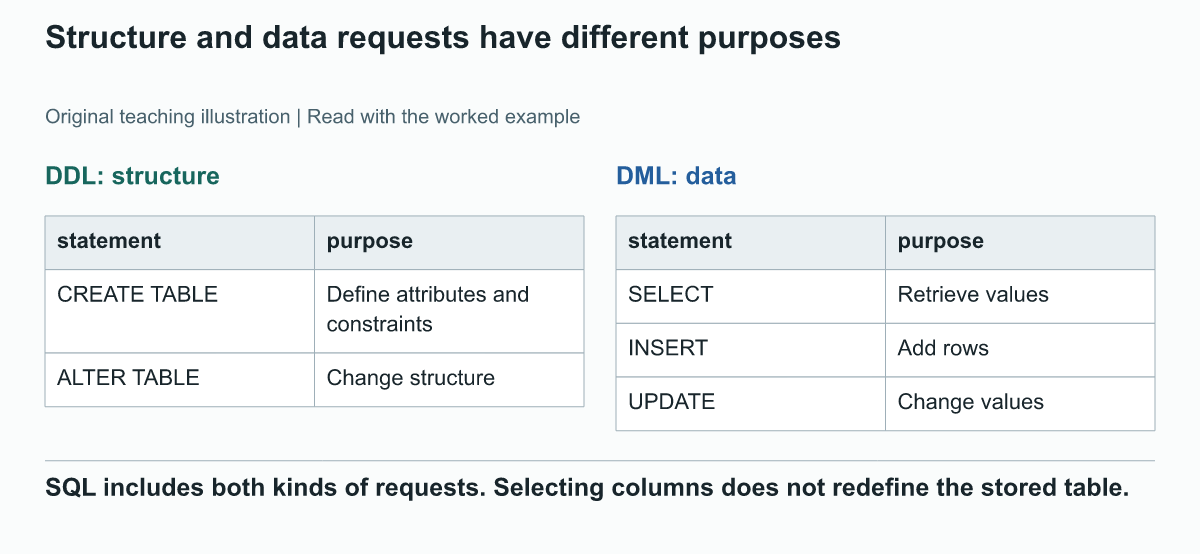

SQL includes both kinds of requests. Selecting columns does not redefine the stored table.


### Read the Diagram

SELECT retrieves values; INSERT and UPDATE change stored data. CREATE TABLE and
ALTER TABLE define or change structure. Retrieving a different set of columns does
not, by itself, change the underlying table's schema.

**Practice:** Classify "add a new course row" and "add a course-description attribute."
Give the reason for each classification. Check whether your request concerns a fact
in the current state or the structure available to all rows.


## 6. Client/Server and Embedded Databases

In a basic **client/server** arrangement, a client sends database requests to a DBMS
server and receives results. The server manages database access. Additional application
layers are possible, but building them is not part of this course.

SQLite normally runs as an **embedded** database engine in the application process.
In our notebook, Python calls SQLite without a separate database-server process.
SQLite can use a file or memory; "embedded" does not mean "always temporary."

**Predict:** Which arrangement needs a separate DBMS server in the diagram? Does our
use of `:memory:` mean SQLite can never save data to a file?


### SQLite does not need a separate DBMS server

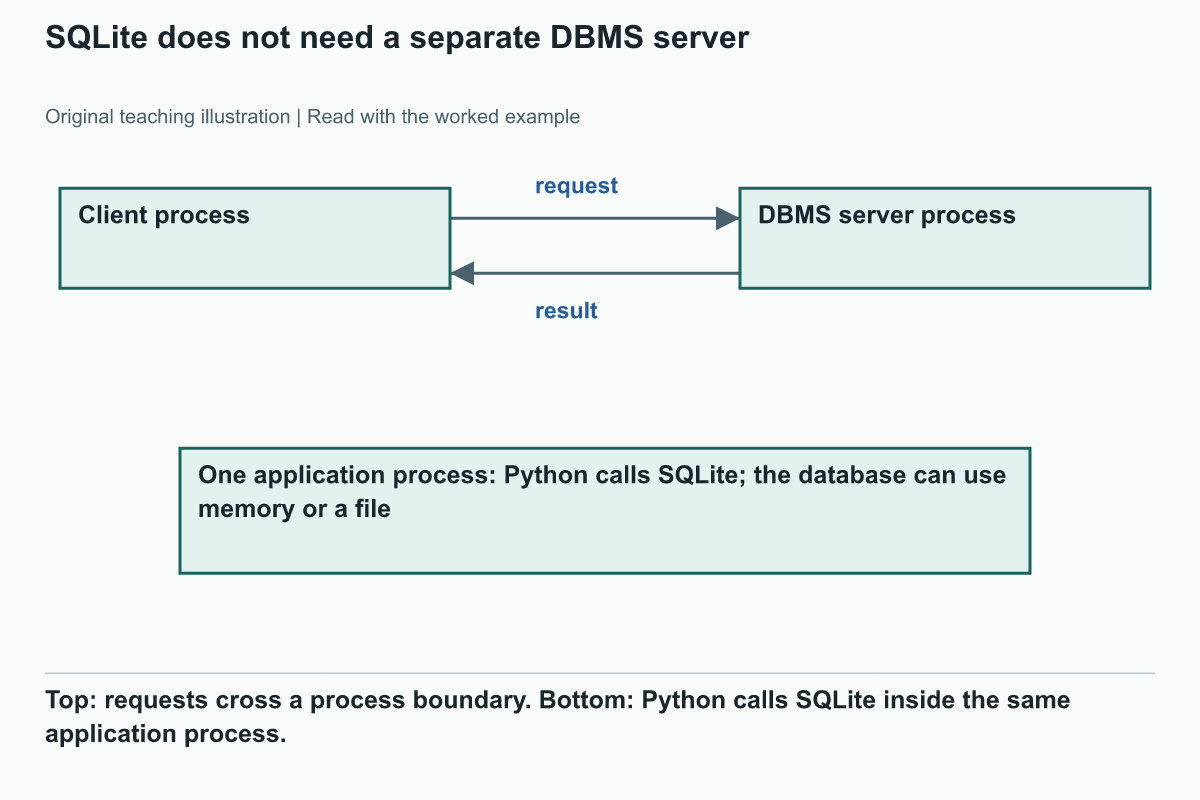

Top: requests cross a process boundary. Bottom: Python calls SQLite inside the same application process.


### Read the Diagram

The client/server example contains a separate server process. Our Python/SQLite
example does not. `:memory:` is the chosen database location for these demonstrations,
not a limitation on SQLite's ability to store files. Closing the connection destroys
this in-memory database; simply closing a browser tab may leave the kernel running.

**Practice:** An application uses SQLite with a saved database file. Explain why
persistence does not turn that arrangement into a separate client/server DBMS.
Judge the location of the database engine, not just the presence of a file.


## Chapter Summary

Models provide descriptive concepts; schemas describe structure; states contain
current values. External, conceptual, and internal descriptions answer different
questions. Data independence requires specified descriptions or interfaces to remain
stable. DDL/DML distinguish purposes, and embedded/client-server distinguish arrangements.

Retain one prediction, one observed result or diagram-based explanation, and either
your correction or the reason your prediction was correct. No additional submission
is required unless assigned. Stop here for the first-meeting architecture selection.

Next, Chapter 3 introduces entities, attributes, and relationships in ER diagrams.
Chapter 4 extends those designs with EER concepts. Relational tables and SQL follow
in Chapters 5-7; they are not additional reading for today's meeting.

Practical reference: [SQLite's serverless architecture](https://www.sqlite.org/serverless.html).
